БИБЛИОТЕКИ И ПОДКЛЮЧЕНИЕ

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import os
import glob
from tqdm import tqdm
from scipy.spatial.distance import cosine

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
hourglass_model_path = '/content/drive/MyDrive/FR_project/best_model.pth'

In [ ]:
FR_model_path = '/content/drive/MyDrive/FR_project/final_face_model_ce.pth'

In [ ]:
image_people_path = '/content/drive/MyDrive/FR_project/people.jpg'

МОДЕЛЬ ДЛЯ ВЫРАВНИВАНИЯ

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)

In [ ]:
class HourglassBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.skip = ResidualBlock(in_channels, out_channels)

        # Level 1: H/2
        self.down1 = nn.Sequential(
            ResidualBlock(in_channels, out_channels // 2),
            nn.MaxPool2d(2, stride=2)
        )

        # Level 2: H/4
        self.down2 = nn.Sequential(
            ResidualBlock(out_channels // 2, out_channels // 2),
            nn.MaxPool2d(2, stride=2)
        )

        # Level 3: H/8
        self.down3 = nn.Sequential(
            ResidualBlock(out_channels // 2, out_channels // 2),
            nn.MaxPool2d(2, stride=2)
        )

        # Level 4: H/16 (самый низкий)
        self.down4 = nn.Sequential(
            ResidualBlock(out_channels // 2, out_channels // 2),
            nn.MaxPool2d(2, stride=2)
        )

        # Bottom (самый низкий уровень)
        self.bottom = nn.Sequential(
            ResidualBlock(out_channels // 2, out_channels // 2),
            ResidualBlock(out_channels // 2, out_channels // 2)
        )

        # Upsampling level 4 -> 3 (H/16 -> H/8)
        self.up4 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            ResidualBlock(out_channels // 2, out_channels // 2)
        )

        # Upsampling level 3 -> 2 (H/8 -> H/4)
        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            ResidualBlock(out_channels // 2, out_channels // 2)
        )

        # Upsampling level 2 -> 1 (H/4 -> H/2)
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            ResidualBlock(out_channels // 2, out_channels // 2)
        )

        # Upsampling level 1 -> original (H/2 -> H)
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            ResidualBlock(out_channels // 2, out_channels)
        )

        # Final - используем обычную свертку вместо ResidualBlock
        # потому что ResidualBlock требует четное количество входных каналов
        # и делает out_channels // 2
        self.final = nn.Sequential(
            nn.Conv2d(out_channels * 2, out_channels, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        skip = self.skip(x)

        # Downsampling path
        d1 = self.down1(x)      # H/2
        d2 = self.down2(d1)     # H/4
        d3 = self.down3(d2)     # H/8
        d4 = self.down4(d3)     # H/16

        # Bottom
        bottom = self.bottom(d4)  # H/16

        # Upsampling path with skip connections
        up4 = self.up4(bottom)    # H/16 -> H/8
        up4 = up4 + d3            # Складываем с d3 (H/8)

        up3 = self.up3(up4)       # H/8 -> H/4
        up3 = up3 + d2            # Складываем с d2 (H/4)

        up2 = self.up2(up3)       # H/4 -> H/2
        up2 = up2 + d1            # Складываем с d1 (H/2)

        up1 = self.up1(up2)       # H/2 -> H
        up1 = up1 + skip          # Складываем с skip (H)

        # Конкатенируем up1 и skip для финальной свертки
        out = self.final(torch.cat([up1, skip], dim=1))

        return out

In [ ]:
class StackedHourglass(nn.Module):
    def __init__(self, in_channels=3, num_stacks=4, num_keypoints=5, hidden_channels=256):
        super().__init__()
        self.num_stacks = num_stacks
        self.num_keypoints = num_keypoints
        self.hidden_channels = hidden_channels

        # Начальная обработка (как в статье)
        self.input_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResidualBlock(64, 128),
            nn.MaxPool2d(2, stride=2),
            ResidualBlock(128, 128),
            ResidualBlock(128, hidden_channels)
        )

        # Стеки
        self.hourglass_stacks = nn.ModuleList()
        self.heads = nn.ModuleList()
        self.intermediate_convs = nn.ModuleList()

        for i in range(num_stacks):
            self.hourglass_stacks.append(
                HourglassBlock(hidden_channels, hidden_channels)
            )

            self.heads.append(
                nn.Conv2d(hidden_channels, num_keypoints, 1)
            )

            if i < num_stacks - 1:
                self.intermediate_convs.append(
                    nn.Sequential(
                        nn.Conv2d(hidden_channels + num_keypoints, hidden_channels, 1),
                        nn.BatchNorm2d(hidden_channels),
                        nn.ReLU(inplace=True)
                    )
                )

    def forward(self, x):
        x = self.input_conv(x)

        all_heatmaps = []
        residual = None

        for i in range(self.num_stacks):
            hg_out = self.hourglass_stacks[i](x)
            heatmap = self.heads[i](hg_out)
            all_heatmaps.append(heatmap)

            if i < self.num_stacks - 1:
                combined = torch.cat([hg_out, heatmap], dim=1)
                x = self.intermediate_convs[i](combined)
                if residual is not None:
                    x = x + residual
                residual = x

        return all_heatmaps

In [ ]:
# Функция для преобразования heatmap в координаты
def heatmap_to_keypoints(heatmap):
    batch_size = heatmap.shape[0]
    num_keypoints = heatmap.shape[1]
    h, w = heatmap.shape[2], heatmap.shape[3]

    keypoints = []
    for b in range(batch_size):
        points = []
        for k in range(num_keypoints):
            hm = heatmap[b, k, :, :]
            _, idx = hm.flatten().max(dim=0)
            y = idx // w
            x = idx % w
            points.append((x.item(), y.item()))
        keypoints.append(points)

    return keypoints

In [ ]:
# Порядок точек как в CelebA / landmarks_dict:
# 0 - левый глаз, 1 - правый глаз, 2 - нос, 3 - левый угол рта, 4 - правый угол рта

# Эталонный шаблон arcface для изображения 112x112,
# масштабируем под нужный итоговый размер
ARCFACE_TEMPLATE_112 = np.array([
    [38.2946, 51.6963],   # левый глаз
    [73.5318, 51.5014],   # правый глаз
    [56.0252, 71.7366],   # нос
    [41.5493, 92.3655],   # левый угол рта
    [70.7299, 92.2041],   # правый угол рта
], dtype=np.float32)

In [ ]:
# эталонные точки для выравнивания
def get_reference_landmarks(output_size=256, base_size=112, zoom=1.15, chin_margin=0.06):
    """
    chin_margin - на сколько (в долях от output_size) сдвинуть эталонные точки
    ВВЕРХ по канве, освобождая больше места снизу под подбородок.
    0.0 - оригинальный ArcFace-баланс (много лба, мало подбородка).
    0.05-0.08 - обычно достаточно, чтобы подбородок влезал целиком.
    """
    template = ARCFACE_TEMPLATE_112 * (output_size / base_size)
    center = np.array([output_size / 2, output_size / 2], dtype=np.float32)
    template = center + (template - center) * zoom

    # сдвигаем landmarks вверх -> меньше лба, больше подбородка
    template[:, 1] -= chin_margin * output_size

    return template

In [ ]:
# получение ключевых точек из изображения
def predict_landmarks(model, image_bgr, device, input_size=256, heatmap_size=64):
    model.eval()
    orig_h, orig_w = image_bgr.shape[:2]

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(image_rgb, (input_size, input_size), interpolation=cv2.INTER_LINEAR)

    tensor = resized.astype(np.float32) / 255.0
    tensor = np.transpose(tensor, (2, 0, 1))
    tensor = torch.FloatTensor(tensor).unsqueeze(0).to(device)

    with torch.no_grad():
        predicted_heatmaps = model(tensor)
        final_heatmap = predicted_heatmaps[-1]

    keypoints_hm = heatmap_to_keypoints(final_heatmap.cpu())[0]

    scale_x = orig_w / heatmap_size
    scale_y = orig_h / heatmap_size
    landmarks = [(x * scale_x, y * scale_y) for (x, y) in keypoints_hm]
    return landmarks

In [ ]:
# выравнивание по точкам
def align_face(image_bgr, landmarks, output_size=256, zoom=1.15, chin_margin=0.13,
               max_scale_ratio=2.5, max_rotation_deg=45):
    src = np.array(landmarks, dtype=np.float32)
    dst = get_reference_landmarks(output_size=output_size, zoom=zoom, chin_margin=chin_margin)

    M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)

    if M is None:
        return cv2.resize(image_bgr, (output_size, output_size)), False

    # проверка на адекватность найденного преобразования
    a, b = M[0, 0], M[0, 1]
    scale = np.sqrt(a**2 + b**2)
    rotation_deg = np.degrees(np.arctan2(b, a))

    is_ok = (1 / max_scale_ratio < scale < max_scale_ratio) and (abs(rotation_deg) < max_rotation_deg)

    aligned = cv2.warpAffine(
        image_bgr, M, (output_size, output_size),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE
    )
    return aligned, is_ok

МОДЕЛЬ ДЛЯ РАСПОЗНАВАНИЯ

In [ ]:
class FaceRecognitionModel(nn.Module):
    def __init__(self, embedding_size=512, num_classes=None, dropout_rate=0.4, freeze_layers=0):
        super(FaceRecognitionModel, self).__init__()

        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        self._freeze_early_layers(freeze_first=freeze_layers)

        self.num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        # Embedding head с BatchNorm
        self.embedding = nn.Sequential(
            nn.BatchNorm1d(self.num_features),
            nn.Dropout(dropout_rate),
            nn.Linear(self.num_features, embedding_size),
            nn.BatchNorm1d(embedding_size),
        )

        if num_classes is not None:
            self.classifier = nn.Linear(embedding_size, num_classes)
        else:
            self.classifier = None

        self._initialize_weights()

    def _freeze_early_layers(self, freeze_first=0):
        if freeze_first <= 0:
            print("All layers will be trained")
            return

        layers_to_freeze = []
        if freeze_first >= 1:
            layers_to_freeze.append(self.backbone.features[0])
            print(f"Frozen: features[0] (first Conv2d)")
        for i in range(1, min(freeze_first, 8)):
            if i < len(self.backbone.features):
                layers_to_freeze.append(self.backbone.features[i])
                print(f"Frozen: features[{i}] (MBConv block {i})")
        for layer in layers_to_freeze:
            for param in layer.parameters():
                param.requires_grad = False
        print(f"Total frozen layers: {len(layers_to_freeze)}")

    def _initialize_weights(self):
        for m in self.embedding.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

        if self.classifier is not None:
            nn.init.xavier_uniform_(self.classifier.weight)
            nn.init.constant_(self.classifier.bias, 0)

    def forward(self, x, return_raw=False):
        """
        Forward pass

        Args:
            x: входные изображения
            return_raw: если True, возвращает ненормализованный эмбеддинг для ArcFace

        Returns:
            если return_raw=False: (embedding_norm, logits) или embedding_norm
            если return_raw=True: (embedding_norm, embedding_raw, logits)
        """
        features = self.backbone(x)
        embedding_raw = self.embedding(features)
        embedding_norm = F.normalize(embedding_raw, p=2, dim=1)

        if self.classifier is not None:
            logits = self.classifier(embedding_norm)
            if return_raw:
                return embedding_norm, embedding_raw, logits
            return embedding_norm, logits
        else:
            return embedding_norm

    def get_embedding(self, x):
        self.eval()
        with torch.no_grad():
            features = self.backbone(x)
            embedding_raw = self.embedding(features)
            embedding_norm = F.normalize(embedding_raw, p=2, dim=1)
            return embedding_norm

In [ ]:
embedding_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

ИНИЦИАЛИЗАЦИЯ И ЗАГРУЗКА ВЕСОВ

In [ ]:
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.6 MB/s eta 0:00:00


In [ ]:
# Детектор лиц
from mtcnn import MTCNN
detector = MTCNN()

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


In [ ]:
# Модель для выравнивания
model = StackedHourglass(
    in_channels=3,
    num_stacks=4,
    num_keypoints=5,
    hidden_channels=256
)
model.to(device)


checkpoint = torch.load('/content/drive/MyDrive/FR_project/best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
print(f"Модель загружена, эпоха: {checkpoint['epoch']+1}, val_loss: {checkpoint['val_loss']:.6f}")

Модель загружена, эпоха: 10, val_loss: 0.001201


In [ ]:
# FR модель
embedding_model = FaceRecognitionModel(
    embedding_size=512,
    num_classes=None,  # Без классификатора для инференса
    dropout_rate=0.0
).to(device)

checkpoint_emb = torch.load(FR_model_path, map_location=device)
embedding_model.load_state_dict(checkpoint_emb['model_state_dict'])
embedding_model.eval()
print(f"Модель распознавания загружена (ver_acc: {checkpoint_emb.get('ver_acc', 'N/A')})")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 175MB/s]


All layers will be trained
Модель распознавания загружена (ver_acc: 0.8575)


ЗАПУСК

In [ ]:
def full_pipeline(image_path, alignment_model, embedding_model, detector, device):
    """
    Полный пайплайн: детекция -> выравнивание -> эмбеддинги
    """
    # 1. Загружаем изображение
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Не удалось загрузить: {image_path}")
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    print(f"Изображение: {os.path.basename(image_path)}")

    # 2. Детекция лиц
    faces = detector.detect_faces(image_rgb)
    print(f"Найдено лиц: {len(faces)}")

    if len(faces) == 0:
        return [], [], image_rgb

    result_image = image_rgb.copy()
    embeddings = []
    faces_info = []

    for i, face in enumerate(faces):
        x, y, w, h = face['box']
        confidence = face['confidence']

        # Рисуем bbox
        cv2.rectangle(result_image, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cv2.putText(result_image, f'Face {i+1}', (x, y-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        # Вырезаем лицо
        face_crop = image[y:y+h, x:x+w]

        # Предсказываем ключевые точки (на кропе)
        landmarks = predict_landmarks(alignment_model, face_crop, device)

        # Выравниваем
        aligned_face, is_ok = align_face(face_crop, landmarks, output_size=256)

        # Получаем эмбеддинг (ИСПОЛЬЗУЕМ МЕТОД МОДЕЛИ!)
        face_rgb = cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB)
        face_tensor = embedding_transform(face_rgb).unsqueeze(0).to(device)
        embedding = embedding_model.get_embedding(face_tensor)  # ← ВОТ ТАК!
        embedding = embedding.cpu().numpy().flatten()

        embeddings.append(embedding)
        faces_info.append({
            'box': (x, y, w, h),
            'confidence': confidence,
            'aligned_face': aligned_face,
            'landmarks': landmarks,
            'is_ok': is_ok
        })

        print(f"Лицо {i+1}: эмбеддинг размером {embedding.shape}")

    return embeddings, faces_info, result_image

In [ ]:
def visualize_and_compare(image_path, alignment_model, embedding_model, detector, device):
    """
    Визуализация результатов и сравнение лиц
    """
    # Запускаем пайплайн
    embeddings, faces_info, result_image = full_pipeline(
        image_path, alignment_model, embedding_model, detector, device
    )

    if len(embeddings) == 0:
        print("Лица не найдены")
        return

    n_faces = len(embeddings)

    # ===== 1. Оригинал с bbox =====
    plt.figure(figsize=(12, 8))
    plt.imshow(result_image)
    plt.title(f'Обнаруженные лица: {n_faces}', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

    # ===== 2. Выровненные лица =====
    fig, axes = plt.subplots(1, n_faces, figsize=(4*n_faces, 5))
    if n_faces == 1:
        axes = [axes]

    for i, info in enumerate(faces_info):
        aligned_rgb = cv2.cvtColor(info['aligned_face'], cv2.COLOR_BGR2RGB)
        axes[i].imshow(aligned_rgb)
        status = "OK" if info['is_ok'] else "Not OK"
        axes[i].set_title(f'Лицо {i+1} {status}\nУверенность: {info["confidence"]:.3f}', fontsize=10)
        axes[i].axis('off')

    plt.suptitle('Выровненные лица', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ===== 3. Сравнение лиц (матрица расстояний) =====
    if n_faces > 1:
        # Вычисляем матрицу расстояний
        dist_matrix = np.zeros((n_faces, n_faces))
        for i in range(n_faces):
            for j in range(n_faces):
                dist_matrix[i, j] = cosine(embeddings[i], embeddings[j])

        # Визуализация матрицы
        plt.figure(figsize=(8, 6))
        sns.heatmap(dist_matrix, annot=True, fmt='.3f',
                   xticklabels=[f'Лицо {i+1}' for i in range(n_faces)],
                   yticklabels=[f'Лицо {i+1}' for i in range(n_faces)],
                   cmap='RdYlGn_r', vmin=0, vmax=1)
        plt.title('Матрица косинусных расстояний между лицами\n'
                 '(0 = одинаковые, 1 = совершенно разные)', fontsize=12)
        plt.show()

        # Вывод результатов
        print("\n" + "="*60)
        print("РАССТОЯНИЯ МЕЖДУ ЛИЦАМИ:")
        print("="*60)
        threshold = 0.6  # Порог для определения одинаковых лиц

        for i in range(n_faces):
            for j in range(i+1, n_faces):
                dist = dist_matrix[i, j]
                is_same = "ОДИНАКОВЫЙ" if dist < threshold else "РАЗНЫЙ"
                print(f"Лицо {i+1} vs Лицо {j+1}: {dist:.4f} → {is_same}")

        print(f"\nПорог для определения одинаковых лиц: {threshold}")

        # Вывод нормализации эмбеддингов
        print("\nПроверка нормализации эмбеддингов:")
        for i, emb in enumerate(embeddings):
            norm = np.linalg.norm(emb)
            print(f"  Лицо {i+1}: норма = {norm:.4f} {'OK' if abs(norm - 1.0) < 0.01 else 'Not OK'}")

    return embeddings, faces_info

Изображение: people.jpg
Найдено лиц: 4
Лицо 1: эмбеддинг размером (512,)
Лицо 2: эмбеддинг размером (512,)
Лицо 3: эмбеддинг размером (512,)
Лицо 4: эмбеддинг размером (512,)


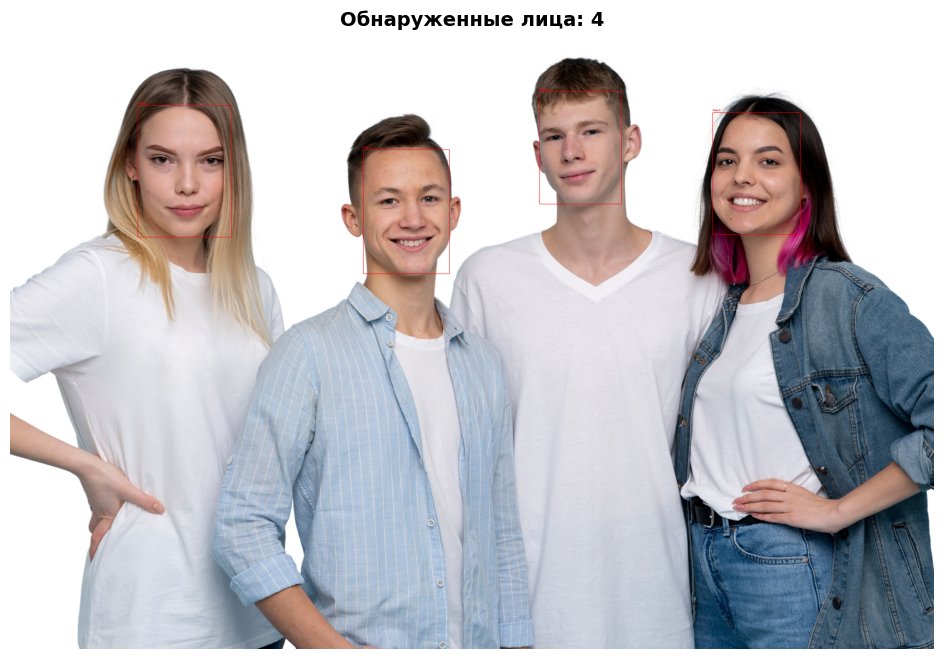

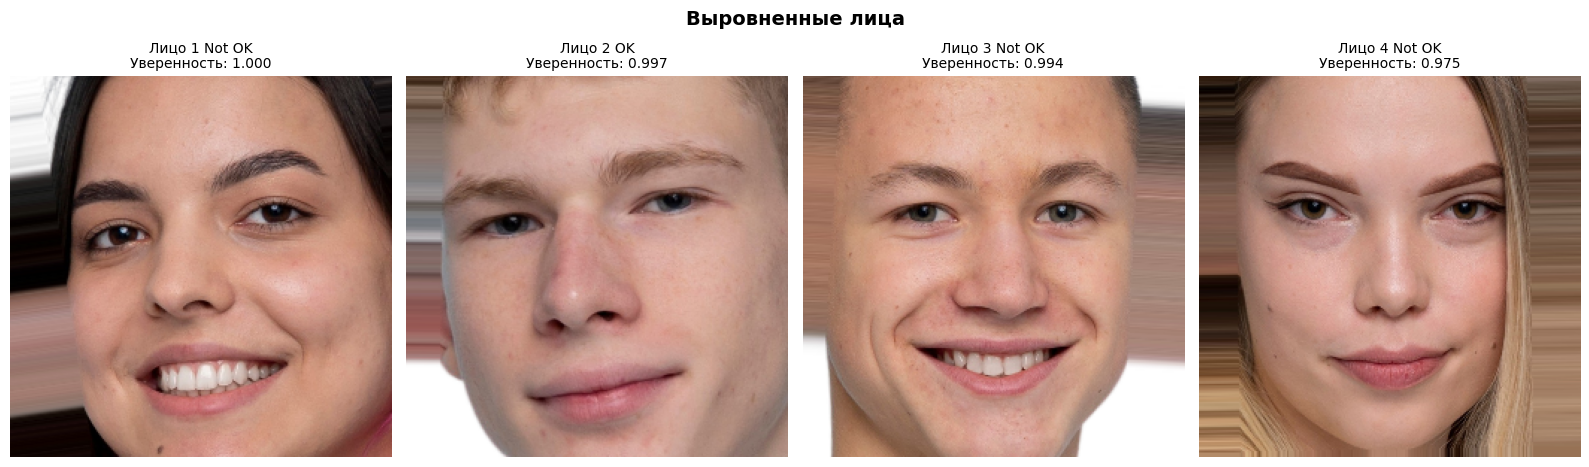

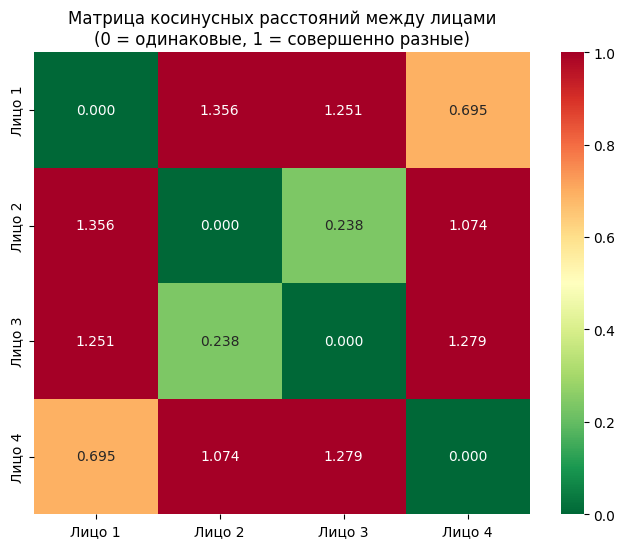


РАССТОЯНИЯ МЕЖДУ ЛИЦАМИ:
Лицо 1 vs Лицо 2: 1.3564 → РАЗНЫЙ
Лицо 1 vs Лицо 3: 1.2506 → РАЗНЫЙ
Лицо 1 vs Лицо 4: 0.6948 → РАЗНЫЙ
Лицо 2 vs Лицо 3: 0.2379 → ОДИНАКОВЫЙ
Лицо 2 vs Лицо 4: 1.0738 → РАЗНЫЙ
Лицо 3 vs Лицо 4: 1.2787 → РАЗНЫЙ

Порог для определения одинаковых лиц: 0.6

Проверка нормализации эмбеддингов:
  Лицо 1: норма = 1.0000 OK
  Лицо 2: норма = 1.0000 OK
  Лицо 3: норма = 1.0000 OK
  Лицо 4: норма = 1.0000 OK


In [ ]:
embeddings, faces_info = visualize_and_compare(
    image_people_path, model, embedding_model, detector, device
)